# 03 干支效应主分析（分组统计 + 显著性 + FDR）

输入：
- `data/cache/index_daily/{ts_code}.csv.gz`
- `data/clean/ganzhi_trade_dates.csv.gz`

输出（每个 ts_code 一份）：
- `data/clean/market_{ts_code}.csv.gz`
- `data/clean/market_ganzhi_{ts_code}.csv.gz`
- `data/clean/ganzhi_stats_{ts_code}.csv`
- `data/clean/ganzhi_tests_{ts_code}.csv`


In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def find_project_root(start: Path | None = None) -> Path:
    here = (start or Path.cwd()).resolve()

    # Typical: notebook is executed under project root or under ./notebooks
    for candidate in [here] + list(here.parents):
        if (candidate / 'AGENTS.md').is_file() and (candidate / 'data').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate

    # Fallback: if executed from a parent folder, look for a child project dir
    for candidate in here.glob('*'):
        if candidate.is_dir() and (candidate / 'AGENTS.md').is_file() and (candidate / 'data').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate

    return here


ROOT = find_project_root()
print('PROJECT_ROOT =', ROOT)


CACHE_DIR = ROOT / 'data/cache'
CLEAN_DIR = ROOT / 'data/clean'
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

INDEX_TS_CODES = [
    '000300.SH',
    '000852.SH',
    '000001.SH',
    '399001.SZ',
]

MIN_N_FOR_JIAZI_PLOT = 30


def fdr_bh(pvals: np.ndarray) -> np.ndarray:
    p = np.asarray(pvals, dtype=float)
    n = p.size
    order = np.argsort(p)
    q = np.empty(n, dtype=float)
    prev = 1.0
    for rank in range(n - 1, -1, -1):
        i = order[rank]
        val = p[i] * n / (rank + 1)
        prev = min(prev, val)
        q[i] = prev
    return np.clip(q, 0.0, 1.0)


def load_index_daily(ts_code: str) -> pd.DataFrame | None:
    path = CACHE_DIR / 'index_daily' / f'{ts_code}.csv.gz'
    if not path.exists():
        return None
    df = pd.read_csv(path, compression='gzip', dtype={'trade_date': str})
    if df.empty:
        return None
    return df.sort_values(['trade_date']).reset_index(drop=True)


def build_market_table(df: pd.DataFrame) -> pd.DataFrame:
    out = df[['ts_code', 'trade_date', 'close', 'pre_close', 'pct_chg']].copy()
    out['trade_date'] = out['trade_date'].astype(str)

    pre = out['pre_close'].replace([0, np.inf, -np.inf], np.nan)
    close = out['close'].replace([0, np.inf, -np.inf], np.nan)

    ret_from_price = close / pre - 1.0
    ret_from_pct = out['pct_chg'] / 100.0

    out['ret_1d'] = ret_from_price
    out.loc[out['ret_1d'].isna(), 'ret_1d'] = ret_from_pct

    out['up'] = (out['ret_1d'] > 0).astype(int)
    return out


def group_stats(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    g = df.groupby(group_col, dropna=False)
    return (
        g.agg(
            n=('ret_1d', 'size'),
            p_up=('up', 'mean'),
            mean_ret=('ret_1d', 'mean'),
            median_ret=('ret_1d', 'median'),
            std_ret=('ret_1d', 'std'),
            q05_ret=('ret_1d', lambda x: float(np.nanquantile(x, 0.05))),
        )
        .reset_index()
    )


def per_group_tests(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    overall_p = float(df['up'].mean())
    overall_mean = float(df['ret_1d'].mean())

    records: list[dict] = []
    for val, sub in df.groupby(group_col, dropna=False):
        n = int(len(sub))
        if n <= 5:
            continue

        k = int(sub['up'].sum())
        p_up = float(sub['up'].mean())
        pval_up = stats.binomtest(k, n, overall_p, alternative='two-sided').pvalue
        records.append(
            {
                'group_type': group_col,
                'group_value': str(val),
                'metric': 'p_up',
                'n': n,
                'effect': p_up - overall_p,
                'p_value': float(pval_up),
            }
        )

        other = df.loc[df[group_col] != val, 'ret_1d']
        if other.notna().sum() > 5 and sub['ret_1d'].notna().sum() > 5:
            t = stats.ttest_ind(sub['ret_1d'], other, equal_var=False, nan_policy='omit')
            pval_ret = float(t.pvalue)
        else:
            pval_ret = np.nan

        records.append(
            {
                'group_type': group_col,
                'group_value': str(val),
                'metric': 'mean_ret',
                'n': n,
                'effect': float(sub['ret_1d'].mean()) - overall_mean,
                'p_value': pval_ret,
            }
        )

    out = pd.DataFrame.from_records(records)
    if out.empty:
        return out

    out['q_value'] = np.nan
    for (gt, metric), idx in out.groupby(['group_type', 'metric']).groups.items():
        pvals = out.loc[idx, 'p_value'].to_numpy(dtype=float)
        ok = np.isfinite(pvals)
        q = np.full_like(pvals, np.nan, dtype=float)
        if ok.sum() > 0:
            q[ok] = fdr_bh(pvals[ok])
        out.loc[idx, 'q_value'] = q
    return out


# load ganzhi calendar

ganzhi_path = CLEAN_DIR / 'ganzhi_trade_dates.csv.gz'
if not ganzhi_path.exists():
    raise FileNotFoundError('Missing data/clean/ganzhi_trade_dates.csv.gz. Run notebook 02 first.')

ganzhi = pd.read_csv(ganzhi_path, compression='gzip', dtype={'trade_date': str})
print('Loaded ganzhi rows =', len(ganzhi))

# Chinese font fallback (plots with Chinese labels)
from matplotlib import font_manager, rcParams

def set_chinese_font():
    candidates = ["Noto Sans CJK SC", "Microsoft YaHei", "SimHei", "Source Han Sans SC", "WenQuanYi Micro Hei"]
    for name in candidates:
        try:
            font_manager.findfont(name, fallback_to_default=False)
            rcParams["font.sans-serif"] = [name]
            rcParams["axes.unicode_minus"] = False
            print(f"Using Chinese font: {name}")
            return
        except Exception:
            continue
    rcParams["axes.unicode_minus"] = False
    print("Warning: no Chinese font found; please install Noto Sans CJK or SimHei for proper labels.")

set_chinese_font()

PROJECT_ROOT = D:\Work\中国传统投资\风水五行阴阳天干地支
Loaded ganzhi rows = 3916
Using Chinese font: Microsoft YaHei


---
ts_code: 000300.SH
saved: D:\Work\中国传统投资\风水五行阴阳天干地支\data\clean\market_000300.SH.csv.gz
saved: D:\Work\中国传统投资\风水五行阴阳天干地支\data\clean\market_ganzhi_000300.SH.csv.gz
saved: D:\Work\中国传统投资\风水五行阴阳天干地支\data\clean\ganzhi_stats_000300.SH.csv
saved: D:\Work\中国传统投资\风水五行阴阳天干地支\data\clean\ganzhi_tests_000300.SH.csv


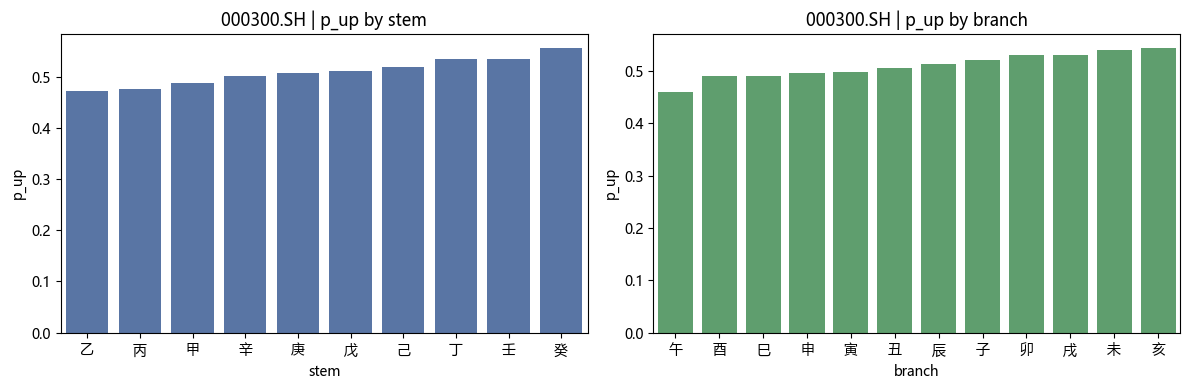

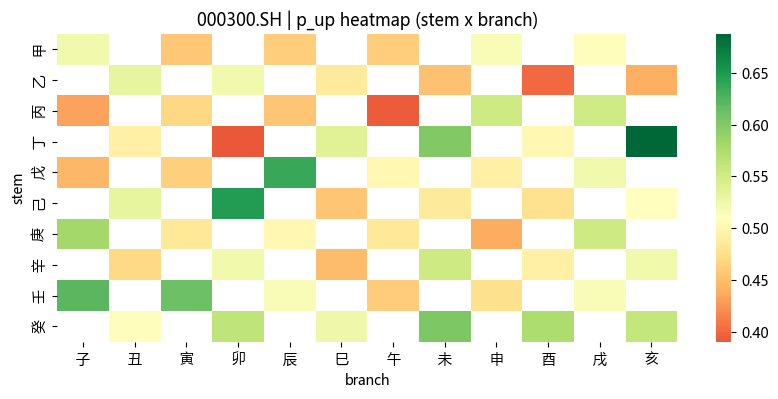

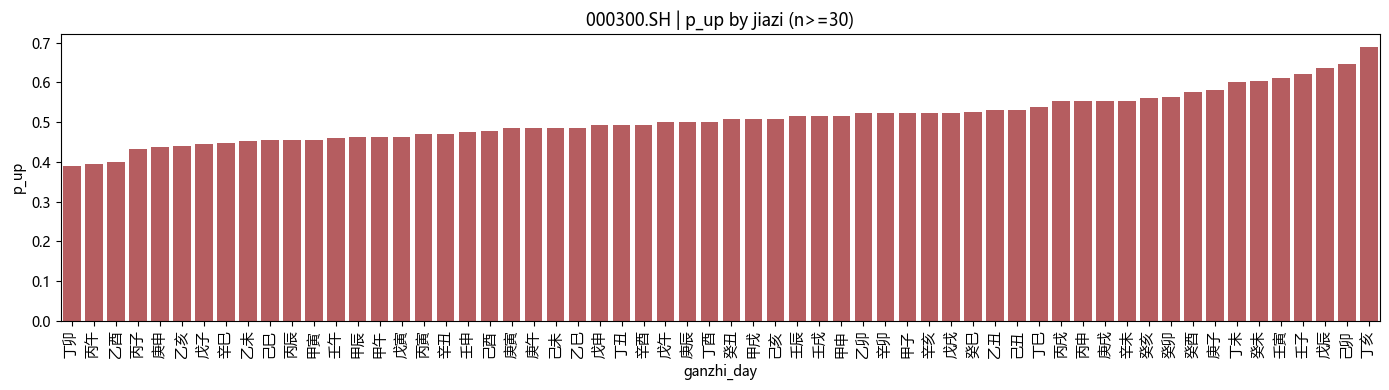

---
ts_code: 000852.SH
saved: D:\Work\中国传统投资\风水五行阴阳天干地支\data\clean\market_000852.SH.csv.gz
saved: D:\Work\中国传统投资\风水五行阴阳天干地支\data\clean\market_ganzhi_000852.SH.csv.gz
saved: D:\Work\中国传统投资\风水五行阴阳天干地支\data\clean\ganzhi_stats_000852.SH.csv
saved: D:\Work\中国传统投资\风水五行阴阳天干地支\data\clean\ganzhi_tests_000852.SH.csv


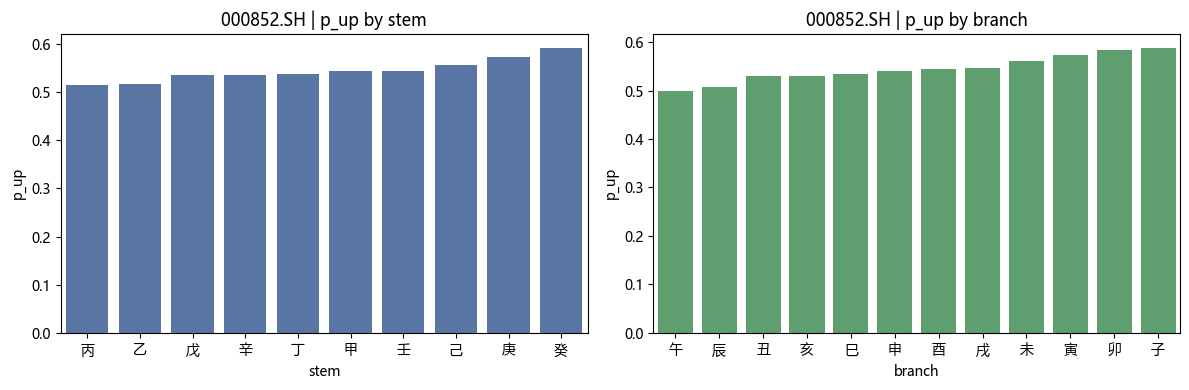

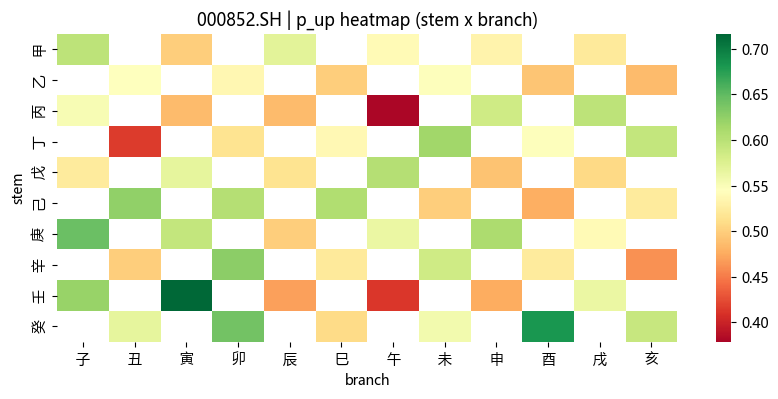

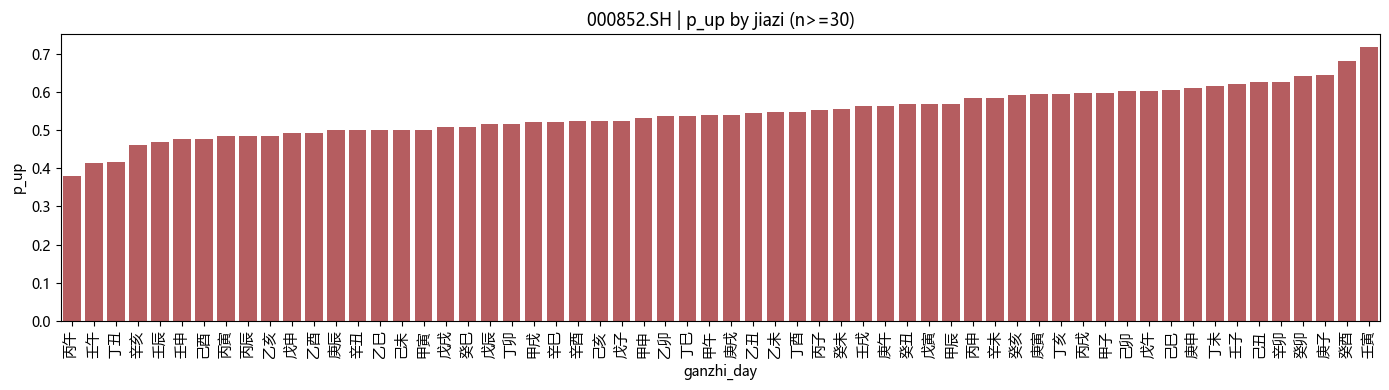

---
ts_code: 000001.SH
saved: D:\Work\中国传统投资\风水五行阴阳天干地支\data\clean\market_000001.SH.csv.gz
saved: D:\Work\中国传统投资\风水五行阴阳天干地支\data\clean\market_ganzhi_000001.SH.csv.gz
saved: D:\Work\中国传统投资\风水五行阴阳天干地支\data\clean\ganzhi_stats_000001.SH.csv
saved: D:\Work\中国传统投资\风水五行阴阳天干地支\data\clean\ganzhi_tests_000001.SH.csv


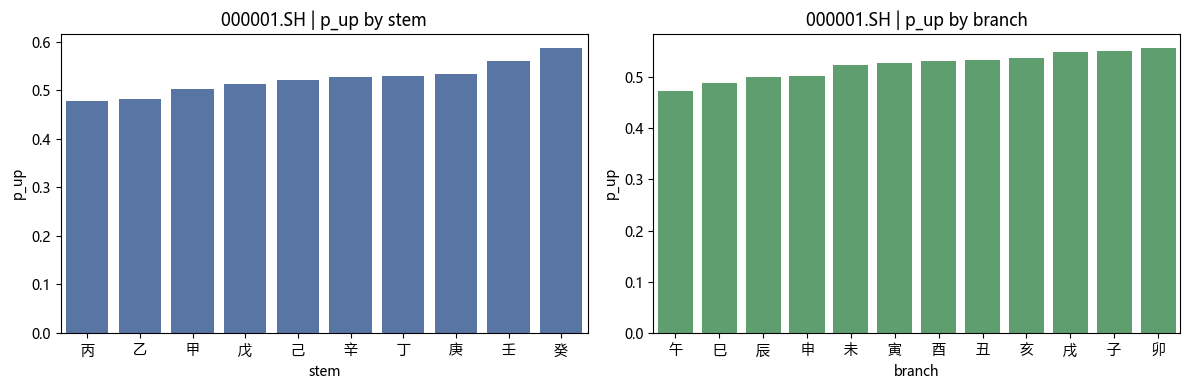

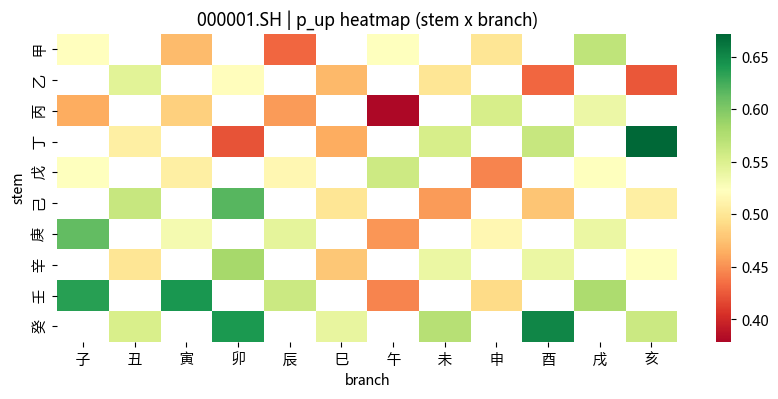

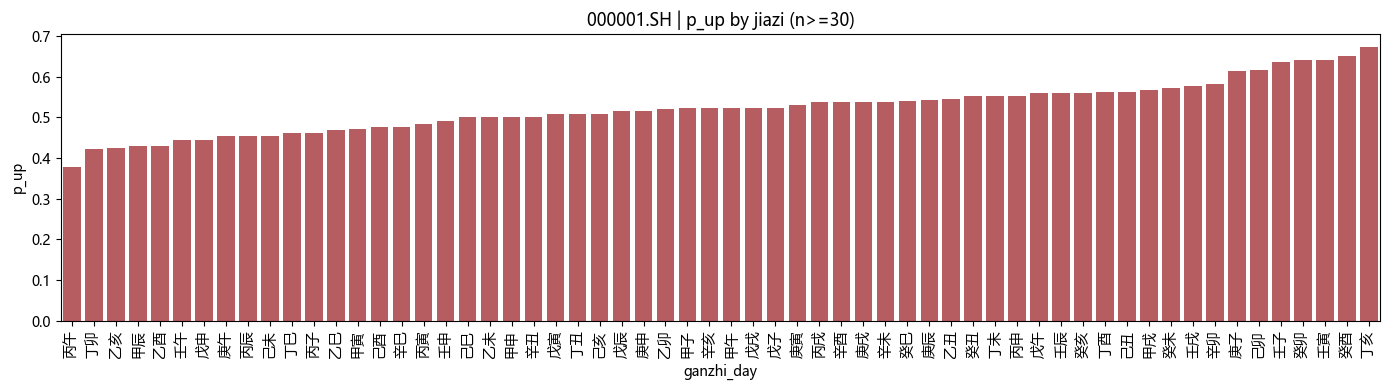

---
ts_code: 399001.SZ
saved: D:\Work\中国传统投资\风水五行阴阳天干地支\data\clean\market_399001.SZ.csv.gz
saved: D:\Work\中国传统投资\风水五行阴阳天干地支\data\clean\market_ganzhi_399001.SZ.csv.gz
saved: D:\Work\中国传统投资\风水五行阴阳天干地支\data\clean\ganzhi_stats_399001.SZ.csv
saved: D:\Work\中国传统投资\风水五行阴阳天干地支\data\clean\ganzhi_tests_399001.SZ.csv


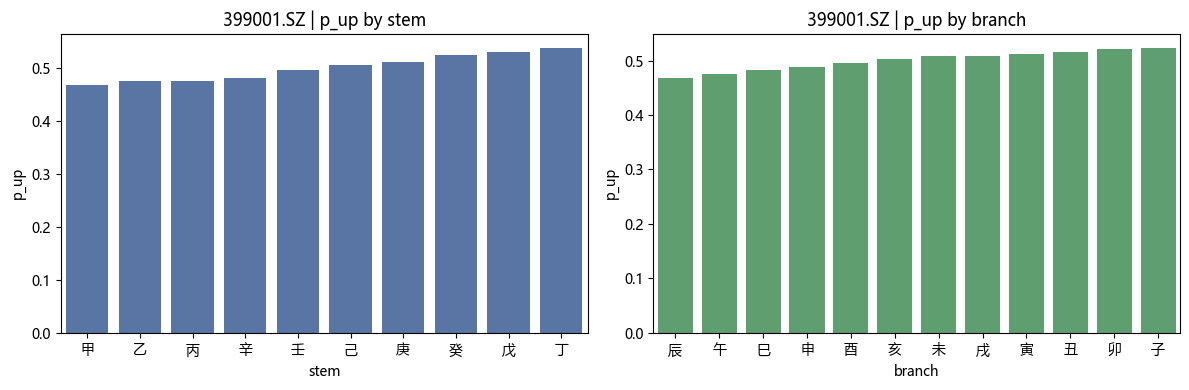

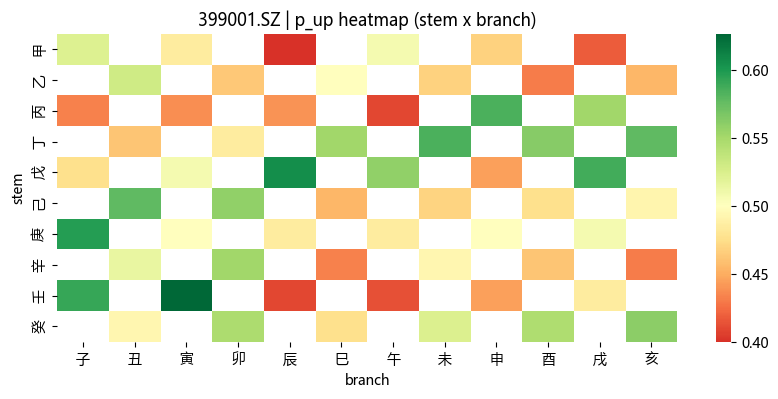

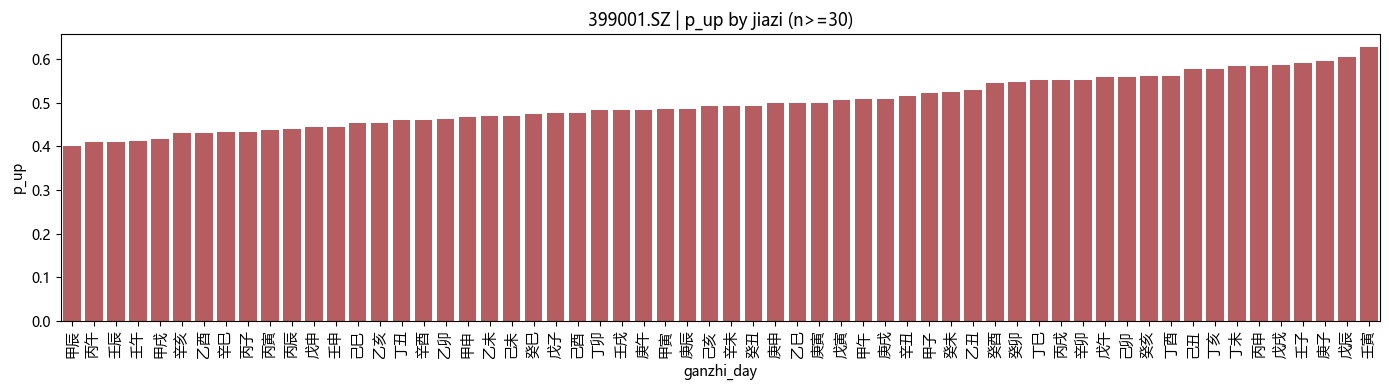

,ts_code,n_days,p_up_all,mean_ret_all
0,000300.SH,3916,0.509448,0.000161
1,000852.SH,3916,0.544944,0.000304
2,000001.SH,3916,0.522983,0.000134
3,399001.SZ,3916,0.500255,0.000129


In [2]:
# 主循环：逐指数输出统计表与检验表
results = []

for ts_code in INDEX_TS_CODES:
    raw = load_index_daily(ts_code)
    if raw is None:
        print('Skip missing:', ts_code)
        continue

    market = build_market_table(raw)
    market_path = CLEAN_DIR / f'market_{ts_code}.csv.gz'
    market.to_csv(market_path, index=False, compression='gzip')

    merged = market.merge(ganzhi, on='trade_date', how='left')
    merged_path = CLEAN_DIR / f'market_ganzhi_{ts_code}.csv.gz'
    merged.to_csv(merged_path, index=False, compression='gzip')

    stats_stem = group_stats(merged, 'stem')
    stats_branch = group_stats(merged, 'branch')
    stats_jiazi = group_stats(merged, 'ganzhi_day')

    stats_all = pd.concat(
        [
            stats_stem.assign(group_type='stem').rename(columns={'stem': 'group_value'}),
            stats_branch.assign(group_type='branch').rename(columns={'branch': 'group_value'}),
            stats_jiazi.assign(group_type='ganzhi_day').rename(columns={'ganzhi_day': 'group_value'}),
        ],
        ignore_index=True,
    )

    stats_path = CLEAN_DIR / f'ganzhi_stats_{ts_code}.csv'
    stats_all.to_csv(stats_path, index=False)

    tests = pd.concat(
        [
            per_group_tests(merged, 'stem'),
            per_group_tests(merged, 'branch'),
            per_group_tests(merged, 'ganzhi_day'),
        ],
        ignore_index=True,
    )

    tests_path = CLEAN_DIR / f'ganzhi_tests_{ts_code}.csv'
    tests.to_csv(tests_path, index=False)

    print('---')
    print('ts_code:', ts_code)
    print('saved:', market_path)
    print('saved:', merged_path)
    print('saved:', stats_path)
    print('saved:', tests_path)

    # quick plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.barplot(data=stats_stem.sort_values('p_up'), x='stem', y='p_up', ax=axes[0], color='#4C72B0')
    axes[0].set_title(f'{ts_code} | p_up by stem')
    sns.barplot(data=stats_branch.sort_values('p_up'), x='branch', y='p_up', ax=axes[1], color='#55A868')
    axes[1].set_title(f'{ts_code} | p_up by branch')
    plt.tight_layout()
    plt.show()

    heat = (
        merged.groupby(['stem', 'branch'])['up']
        .mean()
        .reset_index()
        .pivot(index='stem', columns='branch', values='up')
        .reindex(index=list('甲乙丙丁戊己庚辛壬癸'), columns=list('子丑寅卯辰巳午未申酉戌亥'))
    )

    plt.figure(figsize=(10, 4))
    sns.heatmap(heat, annot=False, cmap='RdYlGn', center=float(merged['up'].mean()))
    plt.title(f'{ts_code} | p_up heatmap (stem x branch)')
    plt.show()

    # Jiazi p_up (filter small n)
    jiazi_plot = stats_jiazi.loc[stats_jiazi['n'] >= MIN_N_FOR_JIAZI_PLOT].sort_values('p_up')
    if len(jiazi_plot) > 0:
        plt.figure(figsize=(14, 4))
        sns.barplot(data=jiazi_plot, x='ganzhi_day', y='p_up', color='#C44E52')
        plt.xticks(rotation=90)
        plt.title(f'{ts_code} | p_up by jiazi (n>={MIN_N_FOR_JIAZI_PLOT})')
        plt.tight_layout()
        plt.show()

    results.append(
        {
            'ts_code': ts_code,
            'n_days': int(len(merged)),
            'p_up_all': float(merged['up'].mean()),
            'mean_ret_all': float(merged['ret_1d'].mean()),
        }
    )

pd.DataFrame(results)
